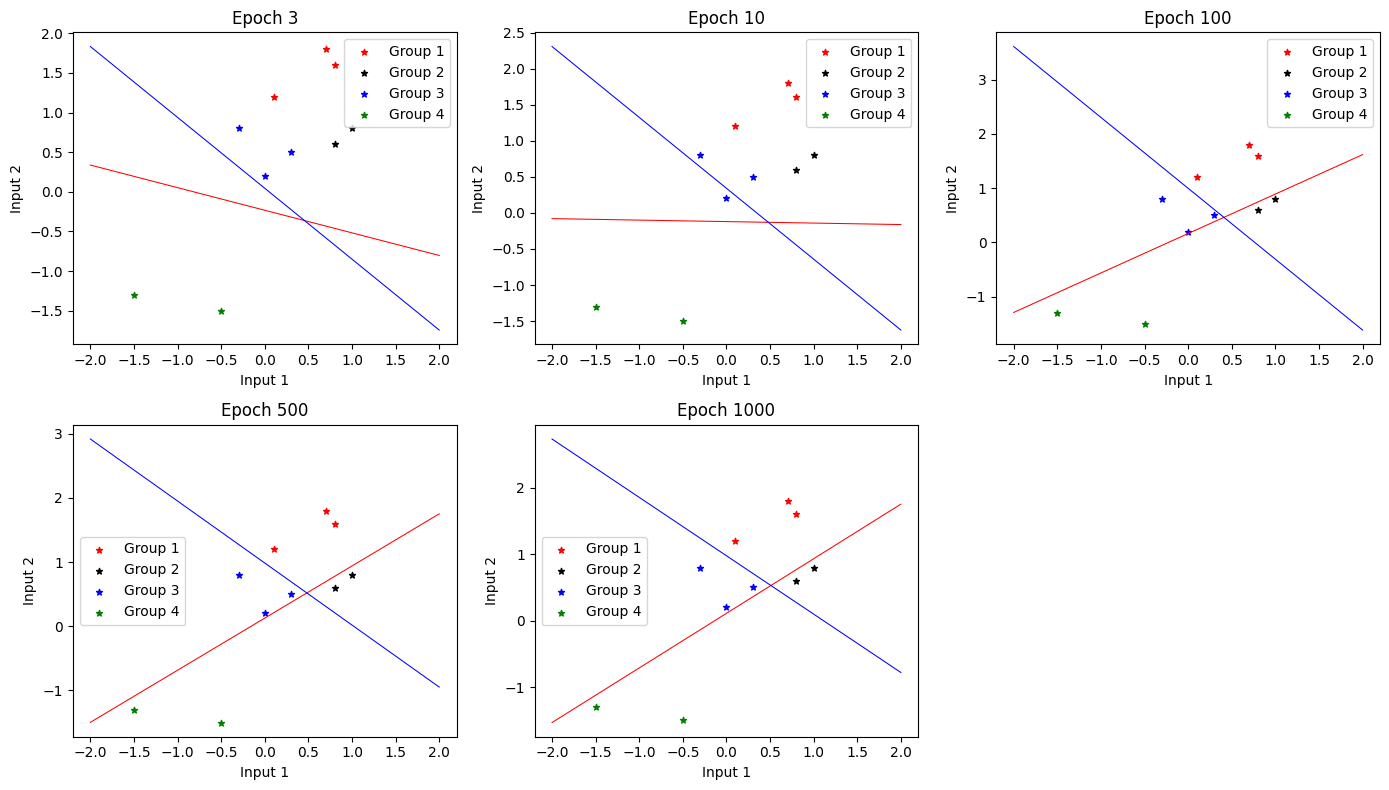

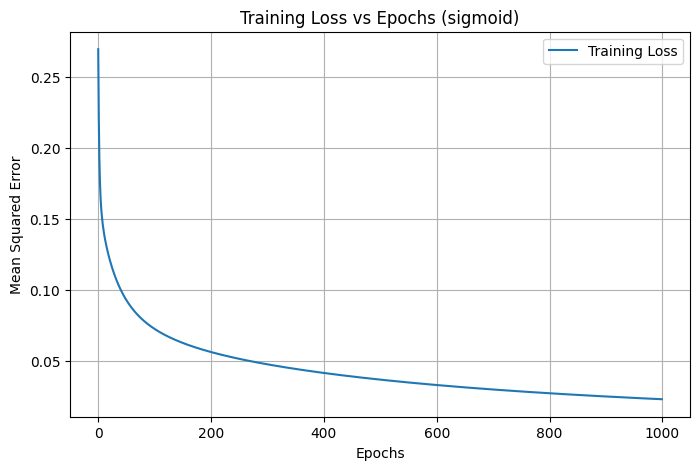

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation
X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3]
])

# Target matrix 
T = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],  # neuron 1
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]   # neuron 2
])

group_assignments = np.array([1, 1, 1, 2, 2, 3, 3, 3, 4, 4])

# Sigmoid and derivative 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# Hyperparameters 
learning_rate = 2
epochs = 1000

# Initialize weights and biases (scaled down for stability)
np.random.seed(42)
# W = np.random.randn(2, 2)*0.01
W = np.random.randn(2, 2) * 0.1
b = np.zeros((2, 1))

loss_history = []
snapshots = {3: None, 10: None, 100: None, 500: None, 1000: None}

# Training (single-layer network, batch GD)
for epoch in range(1, epochs + 1):
    # Forward pass
    Z = np.dot(W, X) + b
    A = sigmoid(Z)

    # Error + loss
    error = A - T
    loss = np.mean(np.square(error))
    loss_history.append(loss)

    # Backward pass (vectorized)
    dZ = error * sigmoid_derivative(A)
    dW = np.dot(dZ, X.T) / X.shape[1]
    db = np.mean(dZ, axis=1, keepdims=True)

    # Update weights
    W -= learning_rate * dW
    b -= learning_rate * db

    # Save snapshots
    if epoch in snapshots:
        snapshots[epoch] = (W.copy(), b.copy())

# Function to plot linear decision boundaries 
def plot_decision_lines(W, b, title):
    xs = np.linspace(-2, 2, 100)

    # Neuron 1: W[0,0]*x + W[0,1]*y + b[0] = 0
    if abs(W[0,1]) > 1e-6:
        ys1 = -(W[0,0]*xs + b[0,0]) / W[0,1]
        plt.plot(xs, ys1, "r-",linewidth=0.75)

    # Neuron 2: W[1,0]*x + W[1,1]*y + b[1] = 0
    if abs(W[1,1]) > 1e-6:
        ys2 = -(W[1,0]*xs + b[1,0]) / W[1,1]
        plt.plot(xs, ys2, "b-",linewidth=0.75)

    # Scatter training points
    colors = {1: 'red', 2: 'black', 3: 'blue', 4: 'green'}
    for group in np.unique(group_assignments):
        mask = group_assignments == group
        plt.scatter(X[0, mask], X[1, mask], c=colors[group], marker="*", s=20, label=f"Group {group}")

    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    # plt.grid(True)
    plt.legend()

# Plot Decision Boundaries at Snapshots 
plt.figure(figsize=(14, 8))
plot_index = 1
for e, params in snapshots.items():
    if params is None:
        continue
    W_snap, b_snap = params
    plt.subplot(2, 3, plot_index)
    plot_decision_lines(W_snap, b_snap, f"Epoch {e}")
    plot_index += 1

plt.tight_layout()
plt.show()
# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Training Loss")
plt.title("Training Loss vs Epochs (sigmoid)")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.legend()
plt.show()


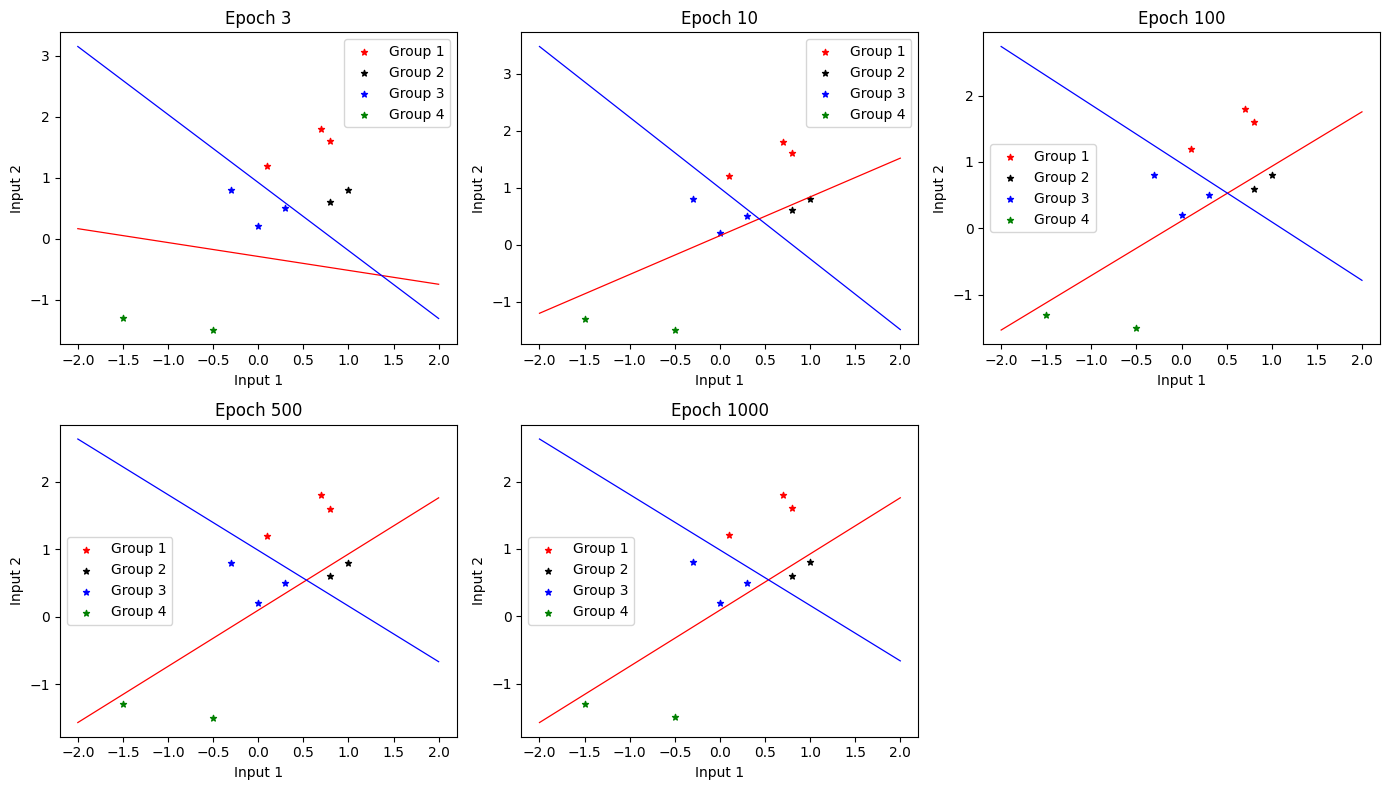

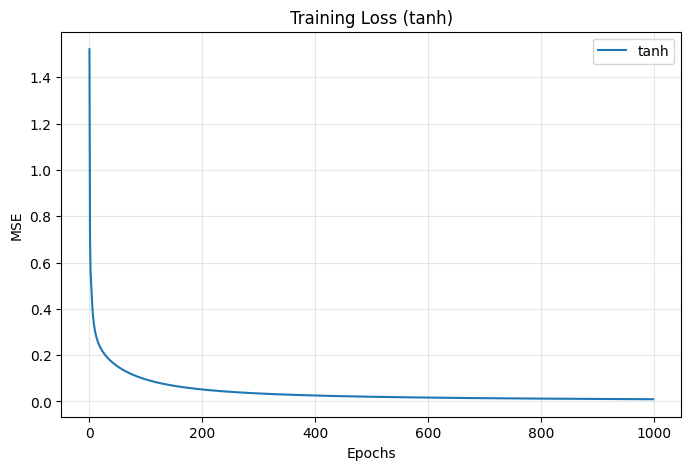

In [139]:

import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3],
], dtype=float)
T01 = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
], dtype=float)
groups = np.array([1, 1, 1, 2, 2, 3, 3, 3, 4, 4])
SNAP_EPOCHS = [3, 10, 100, 500, 1000]

def tanh(z): return np.tanh(z)
def d_tanh_from_a(a): return 1.0 - a**2
def to_pm_one(T): return 2.0*T - 1.0  

def train(lr=1.2, init_scale=0.25, epochs=1000, clip=5.0, seed=42):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((2, 2)) * init_scale
    b = np.zeros((2, 1))
    Tm = to_pm_one(T01)

    loss_hist, snaps = [], {}
    for ep in range(1, epochs+1):
        Z = W @ X + b
        A = tanh(Z)
        err = A - Tm
        loss_hist.append(np.mean(err**2))

        dZ = err * d_tanh_from_a(A)
        dW = (dZ @ X.T) / X.shape[1]
        db = np.mean(dZ, axis=1, keepdims=True)

        # gradient clipping
        nW, nb = np.linalg.norm(dW), np.linalg.norm(db)
        if nW > clip: dW *= clip/nW
        if nb > clip: db *= clip/nb

        W -= lr * dW
        b -= lr * db

        if ep in SNAP_EPOCHS:
            snaps[ep] = (W.copy(), b.copy())
    return W, b, loss_hist, snaps

# Decision boundary plotting 
def plot_decision_lines(W, b, title):
    xs = np.linspace(-2, 2, 200)
    # mid-output surface for tanh: z*=0
    for i, col in enumerate(["r-", "b-"]):
        w0, w1, bi = W[i,0], W[i,1], b[i,0]
        if abs(w1) > 1e-9:
            ys = -(w0*xs + bi) / w1
            plt.plot(xs, ys, col, lw=0.9)

    colors = {1:'red', 2:'black', 3:'blue', 4:'green'}
    for g in np.unique(groups):
        m = (groups == g)
        plt.scatter(X[0,m], X[1,m], c=colors[g], marker="*", s=20, label=f"Group {g}")

    plt.title(title); plt.xlabel("Input 1"); plt.ylabel("Input 2"); plt.legend()

_, _, L, snaps = train()

plt.figure(figsize=(14,8))
idx = 1
for ep in SNAP_EPOCHS:
    if ep not in snaps: continue
    W_ep, b_ep = snaps[ep]
    plt.subplot(2,3,idx)
    plot_decision_lines(W_ep, b_ep, f"Epoch {ep}")
    idx += 1
plt.tight_layout(); plt.show()
plt.figure(figsize=(8,5))
plt.plot(L, label="tanh")
plt.title("Training Loss (tanh)"); plt.xlabel("Epochs"); plt.ylabel("MSE")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()


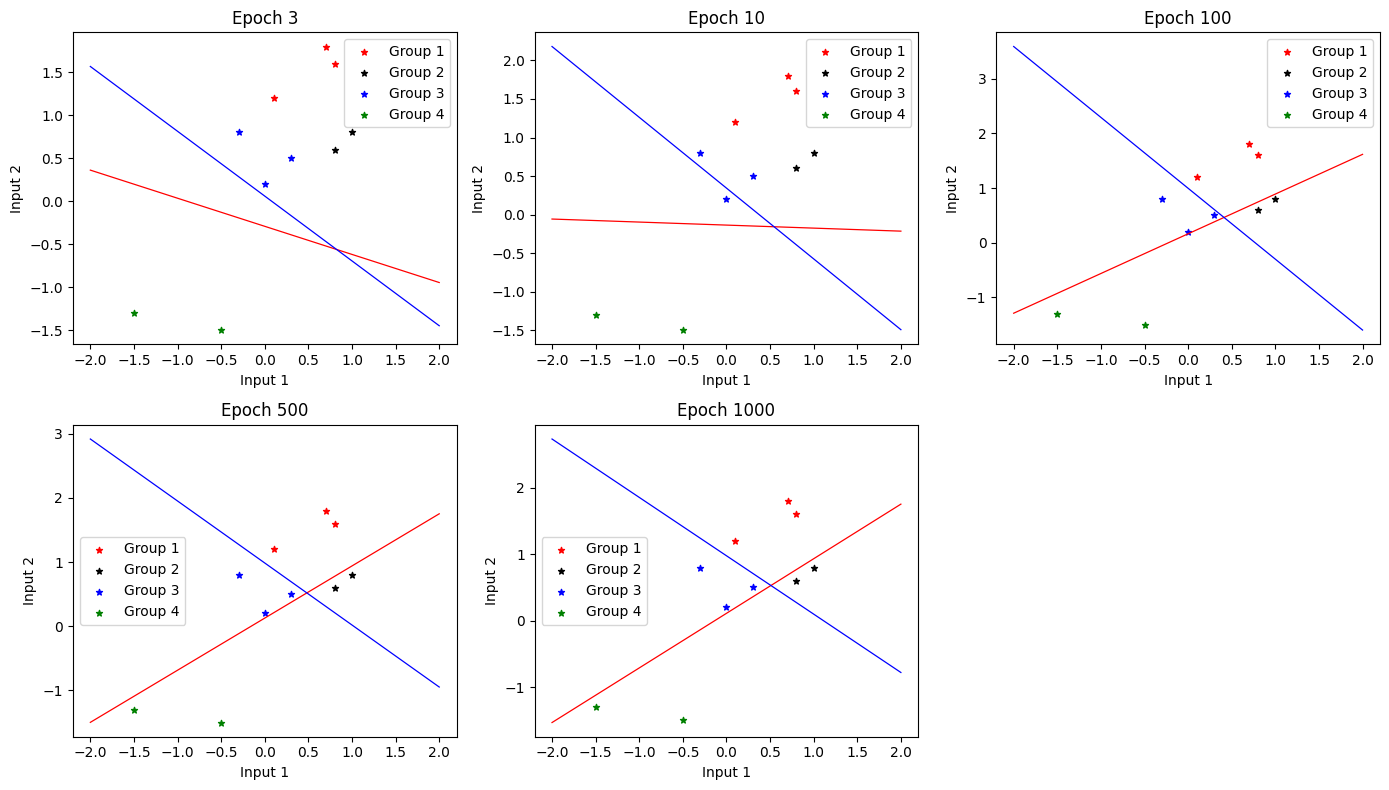

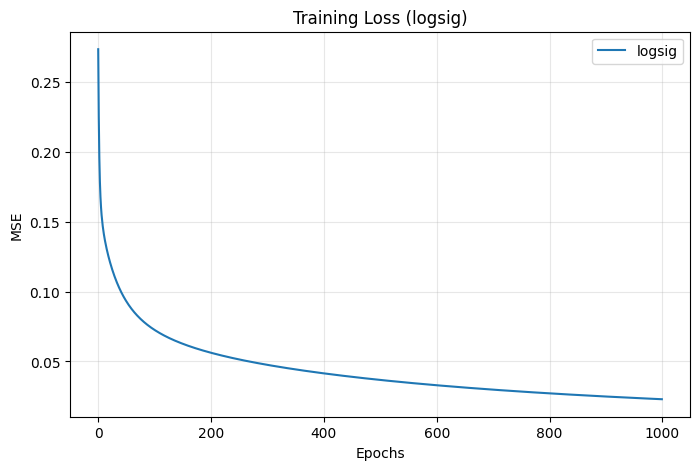

In [142]:

import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3],
], dtype=float)
T01 = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
], dtype=float)
groups = np.array([1, 1, 1, 2, 2, 3, 3, 3, 4, 4])
SNAP_EPOCHS = [3, 10, 100, 500, 1000]

def logsig(z):
    z = np.clip(z, -50, 50)
    return 1.0/(1.0 + np.exp(-z))
def d_logsig_from_a(a): return a*(1.0 - a)
def id_map(T): return T

def train(lr=2, init_scale=0.10, epochs=1000, clip=5.0, seed=42):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((2, 2)) * init_scale
    b = np.zeros((2, 1))
    Tm = id_map(T01)

    loss_hist, snaps = [], {}
    for ep in range(1, epochs+1):
        Z = W @ X + b
        A = logsig(Z)
        err = A - Tm
        loss_hist.append(np.mean(err**2))

        dZ = err * d_logsig_from_a(A)
        dW = (dZ @ X.T) / X.shape[1]
        db = np.mean(dZ, axis=1, keepdims=True)

        nW, nb = np.linalg.norm(dW), np.linalg.norm(db)
        if nW > clip: dW *= clip/nW
        if nb > clip: db *= clip/nb

        W -= lr * dW
        b -= lr * db

        if ep in SNAP_EPOCHS:
            snaps[ep] = (W.copy(), b.copy())
    return W, b, loss_hist, snaps

#Decision boundary
def plot_decision_lines(W, b, title):
    xs = np.linspace(-2, 2, 200)
    # mid-output for logsig: a=0.5 => z*=0
    for i, col in enumerate(["r-", "b-"]):
        w0, w1, bi = W[i,0], W[i,1], b[i,0]
        if abs(w1) > 1e-9:
            ys = -(w0*xs + bi) / w1
            plt.plot(xs, ys, col, lw=0.9)

    colors = {1:'red', 2:'black', 3:'blue', 4:'green'}
    for g in np.unique(groups):
        m = (groups == g)
        plt.scatter(X[0,m], X[1,m], c=colors[g], marker="*", s=20, label=f"Group {g}")

    plt.title(title); plt.xlabel("Input 1"); plt.ylabel("Input 2"); plt.legend()

_, _, L, snaps = train()

plt.figure(figsize=(14,8))
idx = 1
for ep in SNAP_EPOCHS:
    if ep not in snaps: continue
    W_ep, b_ep = snaps[ep]
    plt.subplot(2,3,idx)
    plot_decision_lines(W_ep, b_ep, f"Epoch {ep}")
    idx += 1
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(L, label="logsig")
plt.title("Training Loss (logsig)"); plt.xlabel("Epochs"); plt.ylabel("MSE")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()


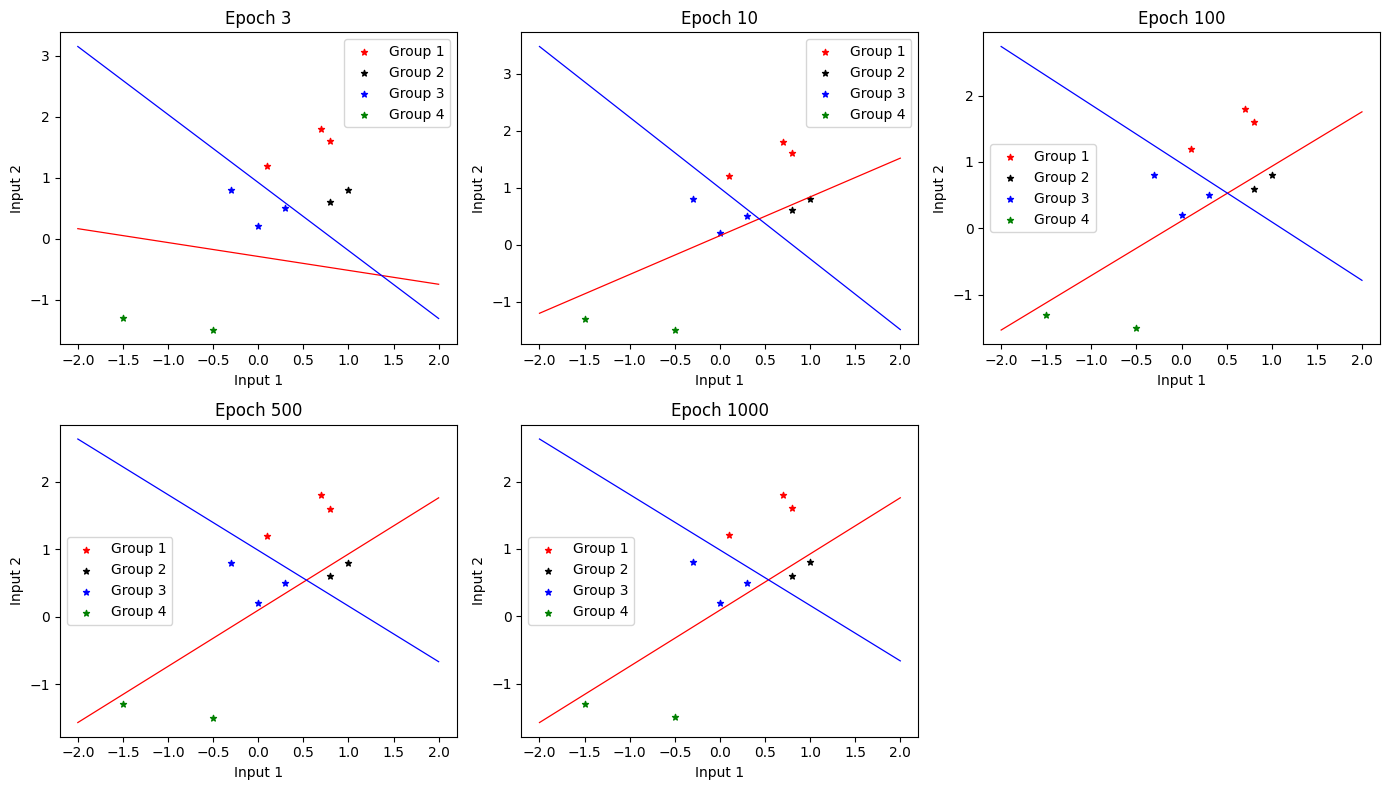

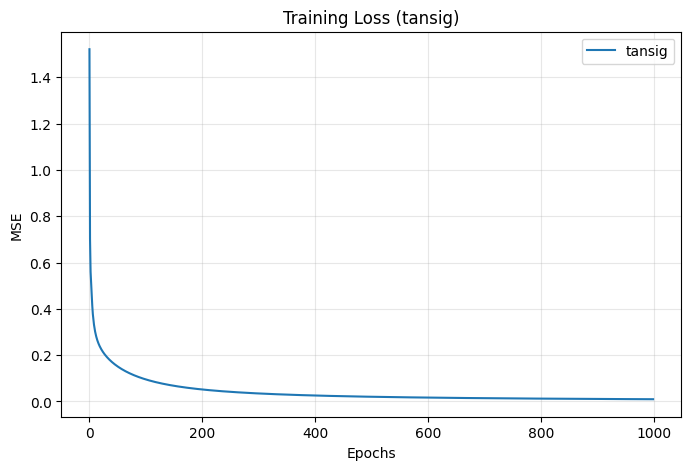

In [143]:

import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3],
], dtype=float)
T01 = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
], dtype=float)
groups = np.array([1, 1, 1, 2, 2, 3, 3, 3, 4, 4])
SNAP_EPOCHS = [3, 10, 100, 500, 1000]
def tansig(z): return np.tanh(z)
def d_tansig_from_a(a): return 1.0 - a**2
def to_pm_one(T): return 2.0*T - 1.0

def train(lr=1.2, init_scale=0.25, epochs=1000, clip=5.0, seed=42):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((2, 2)) * init_scale
    b = np.zeros((2, 1))
    Tm = to_pm_one(T01)

    loss_hist, snaps = [], {}
    for ep in range(1, epochs+1):
        Z = W @ X + b
        A = tansig(Z)
        err = A - Tm
        loss_hist.append(np.mean(err**2))

        dZ = err * d_tansig_from_a(A)
        dW = (dZ @ X.T) / X.shape[1]
        db = np.mean(dZ, axis=1, keepdims=True)

        nW, nb = np.linalg.norm(dW), np.linalg.norm(db)
        if nW > clip: dW *= clip/nW
        if nb > clip: db *= clip/nb

        W -= lr * dW
        b -= lr * db

        if ep in SNAP_EPOCHS:
            snaps[ep] = (W.copy(), b.copy())
    return W, b, loss_hist, snaps

def plot_decision_lines(W, b, title):
    xs = np.linspace(-2, 2, 200)
    # mid-output for tansig: z*=0
    for i, col in enumerate(["r-", "b-"]):
        w0, w1, bi = W[i,0], W[i,1], b[i,0]
        if abs(w1) > 1e-9:
            ys = -(w0*xs + bi) / w1
            plt.plot(xs, ys, col, lw=0.9)

    colors = {1:'red', 2:'black', 3:'blue', 4:'green'}
    for g in np.unique(groups):
        m = (groups == g)
        plt.scatter(X[0,m], X[1,m], c=colors[g], marker="*", s=20, label=f"Group {g}")

    plt.title(title); plt.xlabel("Input 1"); plt.ylabel("Input 2"); plt.legend()

_, _, L, snaps = train()

plt.figure(figsize=(14,8))
idx = 1
for ep in SNAP_EPOCHS:
    if ep not in snaps: continue
    W_ep, b_ep = snaps[ep]
    plt.subplot(2,3,idx)
    plot_decision_lines(W_ep, b_ep, f"Epoch {ep}")
    idx += 1
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(L, label="tansig")
plt.title("Training Loss (tansig)"); plt.xlabel("Epochs"); plt.ylabel("MSE")
plt.grid(True, alpha=0.3); plt.legend(); plt.show()


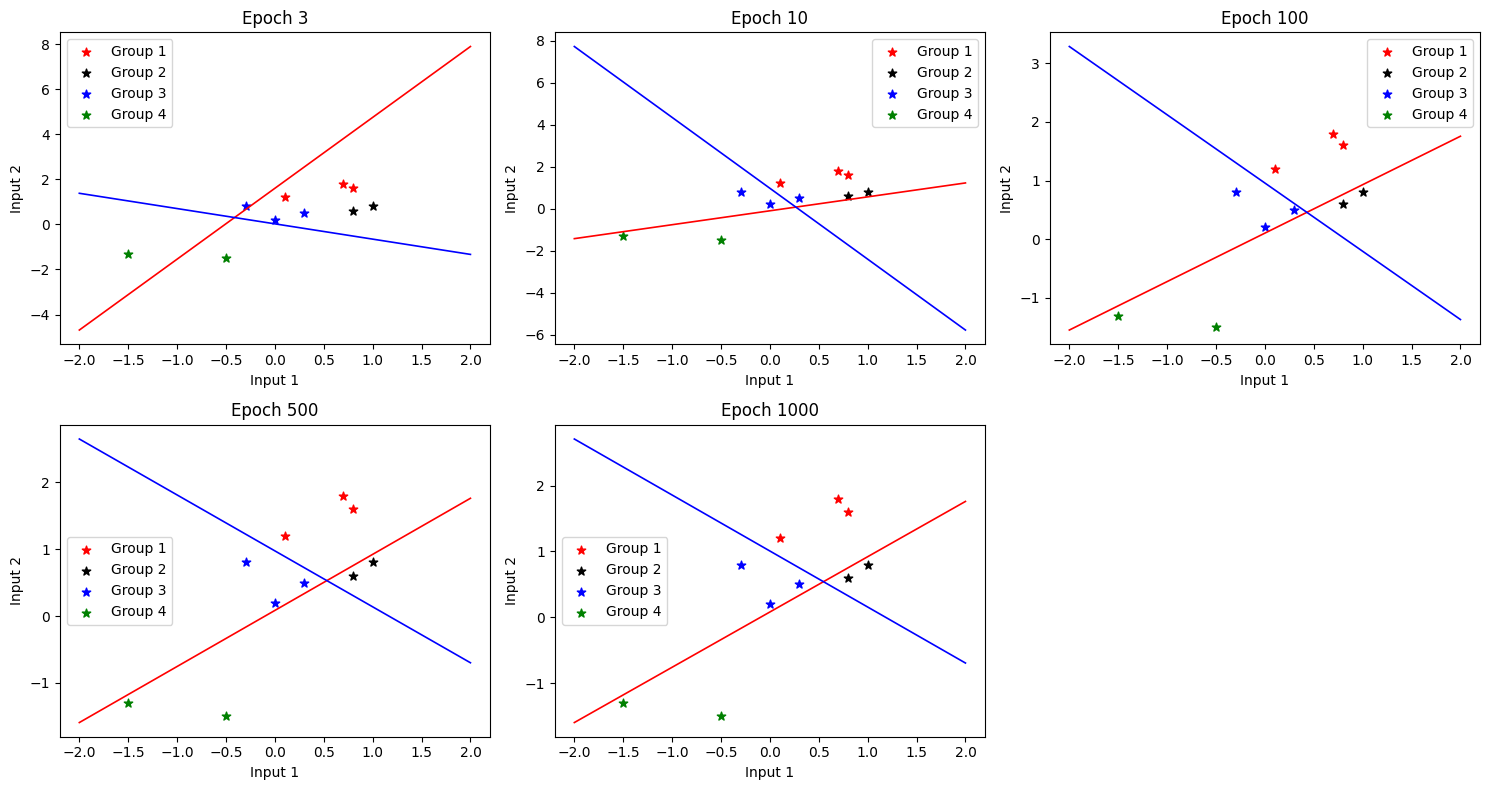

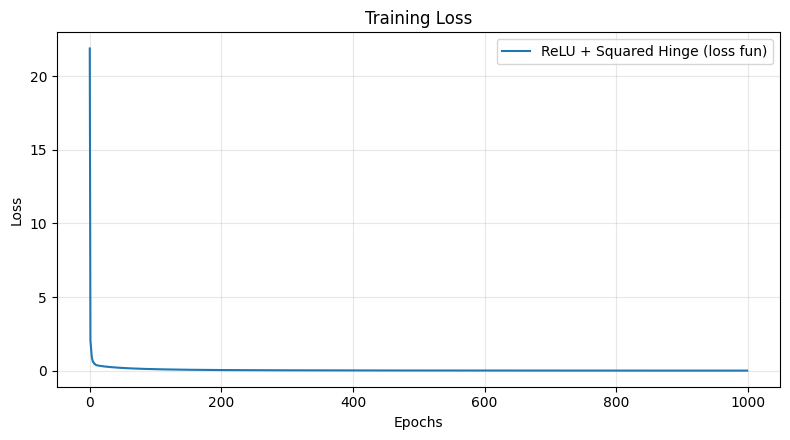

Final squared-hinge loss: 0.000990


In [145]:

import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3]
], dtype=float)

T01 = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
], dtype=float)

groups = np.array([1, 1, 1, 2, 2, 3, 3, 3, 4, 4])
SNAP_EPOCHS = [3, 10, 100, 500, 1000]

# map targets to {-1,+1} for margin loss on logits
Y = 2.0 * T01 - 1.0

def relu(z):  # model activation
    return np.maximum(0.0, z)

def squared_hinge_and_grad(z, y, margin=1.0):
    """
    L = mean( max(0, margin - y*z)^2 )
    dL/dz = mean( -2*y*(margin - y*z)*1{margin - y*z > 0} )
    """
    m = margin - y * z
    mask = (m > 0.0).astype(float)
    loss = np.mean((m * mask) ** 2)
    dLdz = (-2.0 * y * m * mask) / z.shape[1]
    return loss, dLdz

# Training 
def train_relu_margin(
    lr=0.8,
    init_scale=np.sqrt(2/2) * 3.0,   # He-initialization scale *3 
    epochs=1000,
    seed=42,
    clip=5.0,
    b0=0.2,                          # small positive bias avoids dead ReLUs
    margin=1.0,
    l2=0.0
):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((2, 2)) * init_scale
    b = np.full((2, 1), b0, dtype=float)

    losses, snaps = [], {}
    for ep in range(1, epochs + 1):
        z = W @ X + b               # logits
        _ = relu(z)                 # model output (not used in loss)
        loss, dLdz = squared_hinge_and_grad(z, Y, margin=margin)

        if l2 > 0.0:
            loss += 0.5 * l2 * np.sum(W * W)
        losses.append(loss)

        # grads via logits to bypasses ReLU zero-gradient issue
        dW = dLdz @ X.T + l2 * W
        db = np.mean(dLdz, axis=1, keepdims=True)

        # light gradient clipping
        nW, nb = np.linalg.norm(dW), np.linalg.norm(db)
        if nW > clip: dW *= clip / nW
        if nb > clip: db *= clip / nb

        W -= lr * dW
        b -= lr * db

        if ep in SNAP_EPOCHS:
            snaps[ep] = (W.copy(), b.copy())

    return W, b, losses, snaps

#  Plotting 
def plot_snapshot_on_ax(ax, W, b, title):
    xs = np.linspace(-2, 2, 200)

    colors = {1: 'red', 2: 'black', 3: 'blue', 4: 'green'}
    for g in np.unique(groups):
        m = (groups == g)
        ax.scatter(X[0, m], X[1, m], c=colors[g], marker='*', s=40, label=f'Group {g}')

    for i, col in enumerate(['r-', 'b-']):  # 'r-' red, 'b-' blue
        w0, w1, bi = W[i, 0], W[i, 1], b[i, 0]
        if abs(w1) > 1e-9:
            ys = -(w0 * xs + bi) / w1
            ax.plot(xs, ys, col, linewidth=1.2)
        elif abs(w0) > 1e-9:
            x_const = -bi / w0
            ax.axvline(x_const, color=col[0], linewidth=1.2)

    ax.set_title(title)
    ax.set_xlabel("Input 1")
    ax.set_ylabel("Input 2")
    ax.legend(loc='best')

if __name__ == "__main__":
    W, b, L, snaps = train_relu_margin(
        lr=0.8, init_scale=np.sqrt(2/2)*3.0, epochs=1000,
        b0=0.2, margin=1.0, l2=0.0
    )
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
    axes = axes.ravel()

    for i, ep in enumerate(SNAP_EPOCHS):
        if ep in snaps:
            W_ep, b_ep = snaps[ep]
            plot_snapshot_on_ax(axes[i], W_ep, b_ep, f"Epoch {ep}")
        else:
            axes[i].axis('off')


    axes[-1].axis('off')

    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(8, 4.5))
    plt.plot(L, label="ReLU + Squared Hinge (loss fun)")
    plt.title("Training Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Final squared-hinge loss: {L[-1]:.6f}")


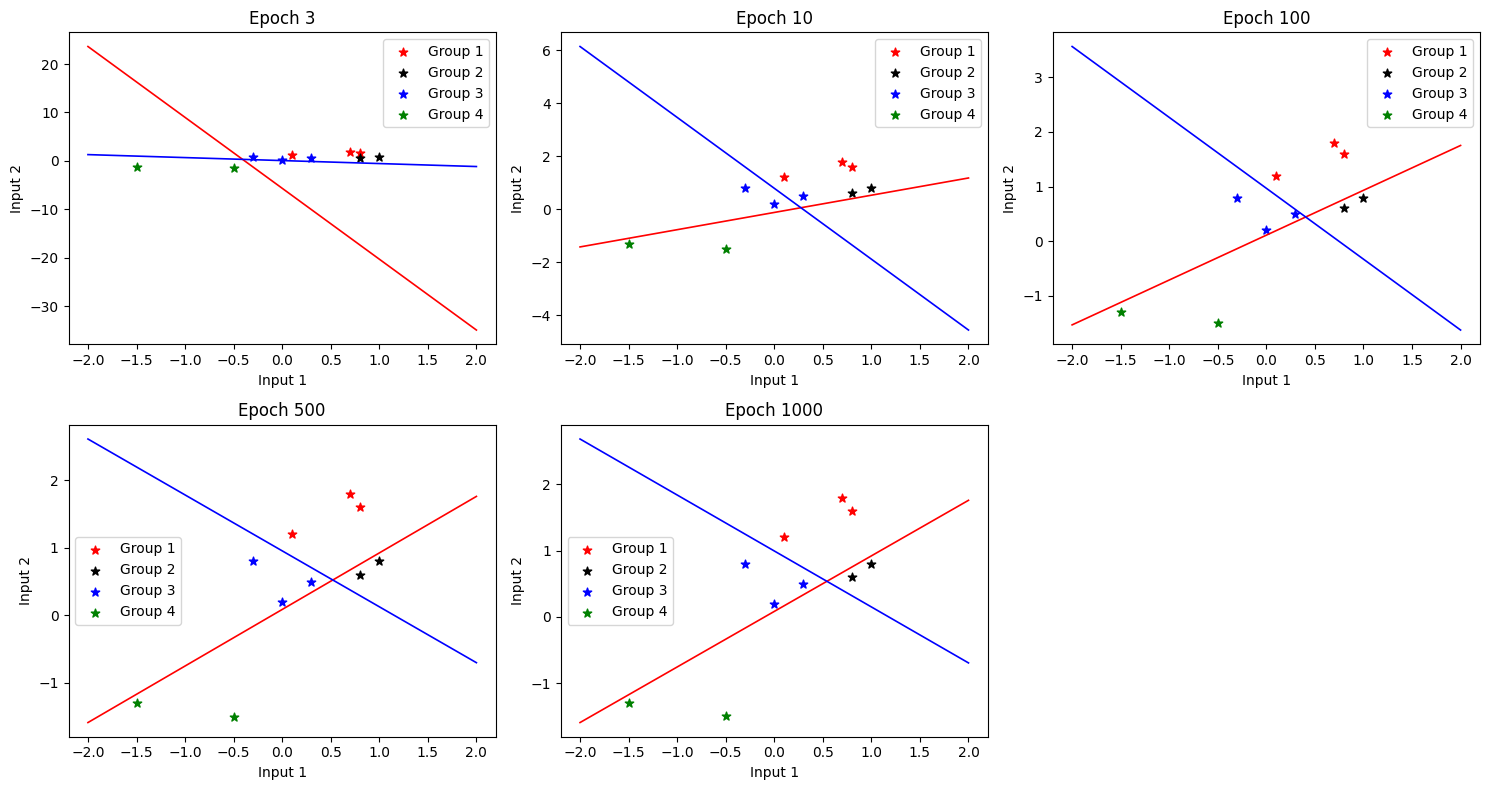

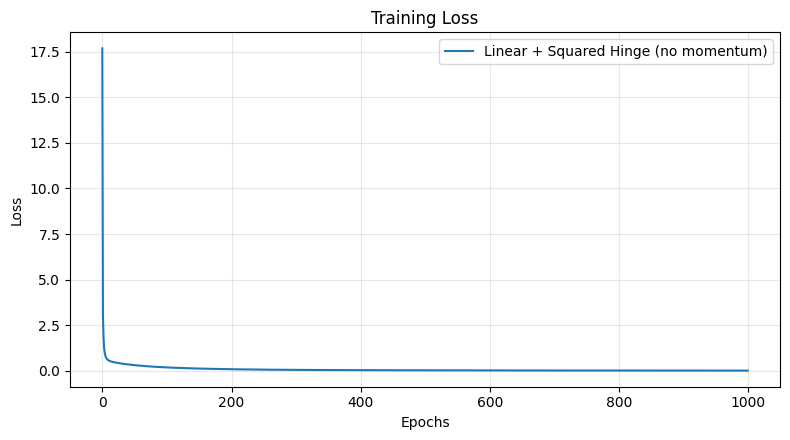

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

#Data 
X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3]
], dtype=float)                        
T01 = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
], dtype=float)                         
Y = 2.0 * T01 - 1.0                     
groups = np.array([1,1,1,2,2,3,3,3,4,4])
SNAP_EPOCHS = [3, 10, 100, 500, 1000]

# Squared hinge loss (on logits)
def sq_hinge_loss_grad(z, y, margin=1.2):
    m = margin - y * z
    mask = (m > 0.0).astype(float)
    loss = np.mean((m * mask)**2)
    dLdz = (-2.0 * y * m * mask) / z.shape[1]
    return loss, dLdz

# Training
def train_linear_margin_gd(
    lr=0.6, init_scale=2.5, b0=0.2, margin=1.2, l2=1e-4, clip=5.0, epochs=1000, seed=42
):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((2, 2)) * init_scale
    b = np.full((2, 1), b0, dtype=float)

    losses, snaps = [], {}
    for ep in range(1, epochs+1):
        z = W @ X + b
        loss, dLdz = sq_hinge_loss_grad(z, Y, margin=margin)
        loss += 0.5 * l2 * np.sum(W * W)

        dW = dLdz @ X.T + l2 * W
        db = np.mean(dLdz, axis=1, keepdims=True)

        nW, nb = np.linalg.norm(dW), np.linalg.norm(db)
        if nW > clip: dW *= clip / nW
        if nb > clip: db *= clip / nb

        W -= lr * dW
        b -= lr * db

        losses.append(loss)
        if ep in SNAP_EPOCHS:
            snaps[ep] = (W.copy(), b.copy())
    return W, b, losses, snaps

# Plotting 
def plot_snapshot_on_ax(ax, W, b, title):
    xs = np.linspace(-2, 2, 200)
    colors = {1:'red', 2:'black', 3:'blue', 4:'green'}
    for g in np.unique(groups):
        m = (groups == g)
        ax.scatter(X[0, m], X[1, m], c=colors[g], marker='*', s=40, label=f'Group {g}')
    for i, col in enumerate(['r-', 'b-']):
        w0, w1, bi = W[i,0], W[i,1], b[i,0]
        if abs(w1) > 1e-9:
            ys = -(w0*xs + bi) / w1
            ax.plot(xs, ys, col, lw=1.2)
        elif abs(w0) > 1e-9:
            ax.axvline(-bi/w0, color=col[0], lw=1.2)
    ax.set_title(title); ax.set_xlabel("Input 1"); ax.set_ylabel("Input 2")
    ax.legend(loc='best')

#  Run 
W,b,L,snaps = train_linear_margin_gd()
fig, axes = plt.subplots(2,3, figsize=(15,8)); axes = axes.ravel()
for i, ep in enumerate([3,10,100,500,1000]):
    if ep in snaps: plot_snapshot_on_ax(axes[i], *snaps[ep], f"Epoch {ep}")
    else: axes[i].axis('off')
axes[-1].axis('off'); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4.5))
plt.plot(L, label="Linear + Squared Hinge (no momentum)")
plt.title("Training Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


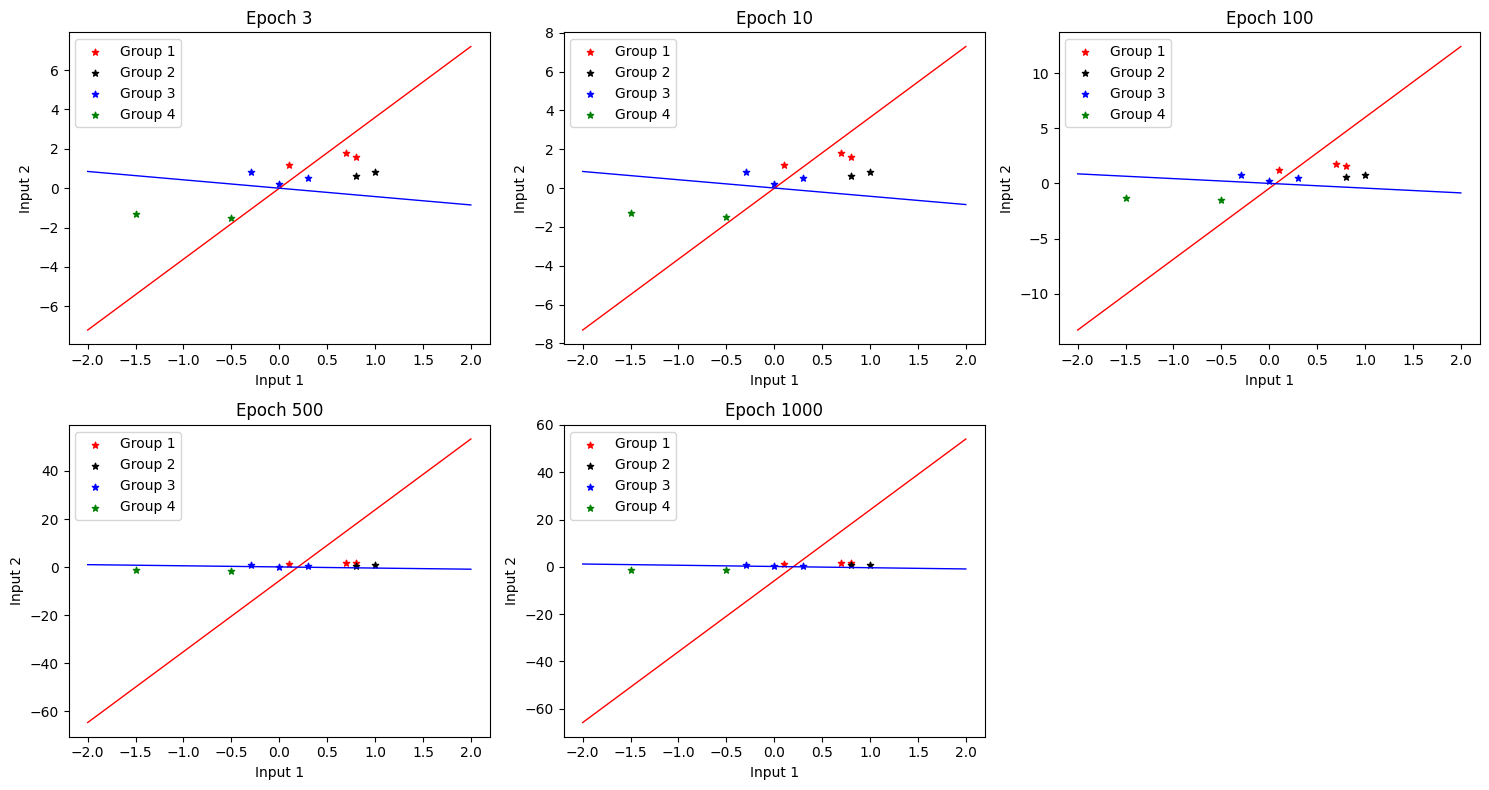

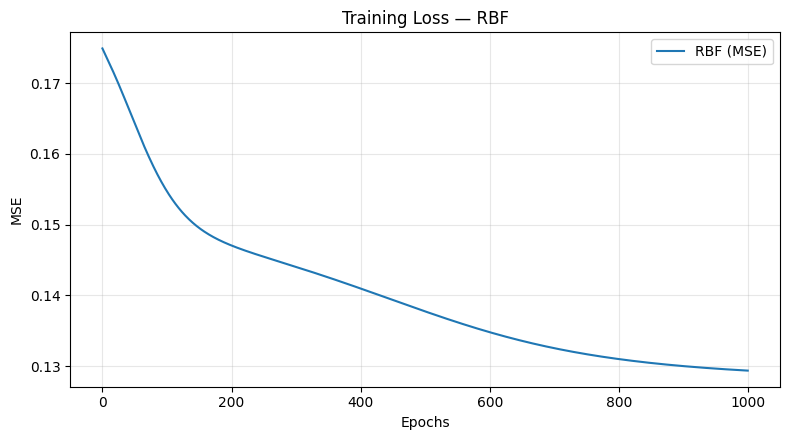

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------- Data ----------------------------
X = np.array([
    [0.1, 0.7, 0.8, 0.8, 1.0, 0.3, 0.0, -0.3, -0.5, -1.5],
    [1.2, 1.8, 1.6, 0.6, 0.8, 0.5, 0.2, 0.8, -1.5, -1.3]
], dtype=float)
T = np.array([
    [1, 1, 1, 0, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
], dtype=float)
group_assignments = np.array([1, 1, 1, 2, 2, 3, 3, 3, 4, 4])
SNAP_EPOCHS = [3, 10, 100, 500, 1000]

# ---------------------------- RBF -----------------------------
def radialbasis(z, gamma=1.0):
    return np.exp(-gamma * np.square(z))     # output in (0,1]

def radialbasis_derivative(z, a, gamma=1.0):
    return -2.0 * gamma * z * a              # da/dz

def train_rbf(lr=0.1, init_scale=10, gamma=1.0,
              epochs=1000, l2=1e-4, clip=5.0, seed=42):
    np.random.seed(seed)
    W = np.random.randn(2, 2) * init_scale
    b = np.zeros((2, 1))
    loss_history, snapshots = [], {}
    N = X.shape[1]

    for ep in range(1, epochs + 1):
        Z = W @ X + b
        A = radialbasis(Z, gamma)
        E = A - T
        loss = 0.5 * np.mean(E**2) + 0.5 * l2 * np.sum(W * W)
        loss_history.append(loss)

        dA = E / N
        dZ = dA * radialbasis_derivative(Z, A, gamma)
        dW = dZ @ X.T + l2 * W
        db = np.mean(dZ, axis=1, keepdims=True)

        # simple gradient clipping to keep big inits stable
        nW, nb = np.linalg.norm(dW), np.linalg.norm(db)
        if nW > clip: dW *= clip / nW
        if nb > clip: db *= clip / nb

        W -= lr * dW
        b -= lr * db

        if ep in SNAP_EPOCHS:
            snapshots[ep] = (W.copy(), b.copy())

    return W, b, loss_history, snapshots

def plot_rbf_lines(ax, W, b, title, gamma=1.0, mode="z0"):
    """
    mode="z0": plot z=0 (single straight line per neuron; matches your earlier style)
    mode="mid": plot a=0.5 for RBF => z=±sqrt(ln2/gamma) (two parallel lines per neuron)
    """
    xs = np.linspace(-2, 2, 400)
    if mode == "mid":
        zstars = [np.sqrt(np.log(2.0)/gamma), -np.sqrt(np.log(2.0)/gamma)]
    else:
        zstars = [0.0]

    # data points
    colors = {1:'red', 2:'black', 3:'blue', 4:'green'}
    for g in np.unique(group_assignments):
        m = (group_assignments == g)
        ax.scatter(X[0, m], X[1, m], c=colors[g], marker="*", s=22, label=f"Group {g}")

    # lines for each neuron at chosen z*
    for i, col in enumerate(['r-', 'b-']):
        w0, w1, bi = W[i,0], W[i,1], b[i,0]
        for z0 in zstars:
            if abs(w1) > 1e-9:
                ys = -(w0 * xs + bi - z0) / w1
                ax.plot(xs, ys, col, lw=1.0)
            elif abs(w0) > 1e-9:
                ax.axvline((z0 - bi) / w0, color=col[0], lw=1.0)

    ax.set_title(title); ax.set_xlabel("Input 1"); ax.set_ylabel("Input 2")
    ax.legend(loc="best")


W, b, L, snaps = train_rbf(lr=0.2, init_scale=5.0, gamma=1.0, epochs=1000)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for k, ep in enumerate([3, 10, 100, 500, 1000]):
    if ep in snaps:
        We, be = snaps[ep]
        plot_rbf_lines(axes[k], We, be, f"Epoch {ep}", gamma=1.0, mode="z0")  # or mode="mid"
    else:
        axes[k].axis("off")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

# Loss curve below
plt.figure(figsize=(8, 4.5))
plt.plot(L, label="RBF (MSE)")
plt.title("Training Loss — RBF")
plt.xlabel("Epochs"); plt.ylabel("MSE")
plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()
